# OpenSourcePulse — Repository Health Score

## Evidence-Driven Repository Intelligence

### Objective

Construct an interpretable multidimensional Repository Health Score using
patterns identified during exploratory data analysis.

### Core Principle

Repository popularity is not equivalent to repository health.

The score therefore combines five complementary dimensions:

1. Popularity
2. Recent Activity
3. Maintenance
4. Community
5. Collaboration

Each dimension contributes equally to the initial score because no external
ground-truth health label is available.

### Methodological Principles

- Preserve genuine observations and outliers.
- Use robust percentile-based normalization.
- Avoid double-counting highly correlated variables where possible.
- Do not treat API-unavailable measurements as zero.
- Report data availability alongside the score.
- Interpret the score comparatively within the analytical sample.
- Use PCA and sensitivity analysis as validation tools rather than defining
  health weights directly.

### Scope

The score is an analytical index rather than an objective or universally
accepted measure of repository quality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
df = pd.read_csv(
    "../data/processed/repository_features_clean.csv"
)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (300, 48)


,repo_id,repo_name,owner,full_name,description,html_url,language,topics,license,created_at,updated_at,pushed_at,stars,forks,watchers,open_issues,size_kb,default_branch,is_fork,archived,repository_age_days,repository_age_years,days_since_update,days_since_push,contributors_count,total_contributions,top_contributor_contributions,top_contributor_share,commits_365d,active_months,peak_monthly_commits,mean_monthly_commits,monthly_commit_std,activity_consistency,status,collected_commits,fork_star_ratio,issues_per_star,commits_per_active_month,language_normalized,log1p_stars,log1p_forks,log1p_open_issues,log1p_size_kb,log1p_commits_365d,log1p_contributors_count,log1p_total_contributions,log1p_peak_monthly_commits
0,192904,pymc,pymc-devs,pymc-devs/pymc,Bayesian Modeling and Probabilistic Programmin...,https://github.com/pymc-devs/pymc,Python,bayesian-inference|mcmc|probabilistic-programm...,NOASSERTION,2009-05-05 09:43:50+00:00,2026-09-17 02:27:02+00:00,2026-09-14 17:31:40+00:00,9754,2301,9754,503,546029,main,False,False,6345,17.371663,1,3,328.0,7558.0,1028.0,0.136015,280.0,13.0,48.0,21.538462,13.220031,1.000000,success,280,0.235903,0.051569,21.538462,python,9.185535,7.741534,6.222576,13.210429,5.638355,5.796058,8.930494,3.891820
1,374228,RestSharp,restsharp,restsharp/RestSharp,Simple REST and HTTP API Client for .NET,https://github.com/restsharp/RestSharp,C#,No topics specified,Apache-2.0,2009-11-16 02:01:45+00:00,2026-09-16 20:48:34+00:00,2026-09-07 22:42:25+00:00,9824,2299,9824,37,41466,dev,False,False,6150,16.837782,1,10,266.0,2048.0,758.0,0.370117,61.0,7.0,20.0,8.714286,6.317022,0.538462,success,61,0.234019,0.003766,8.714286,c#,9.192685,7.740664,3.637586,10.632653,4.127134,5.587249,7.625107,3.044522
2,443962,FluentValidation,FluentValidation,FluentValidation/FluentValidation,A popular .NET validation library for building...,https://github.com/FluentValidation/FluentVali...,C#,No topics specified,Apache-2.0,2009-12-20 19:17:03+00:00,2026-09-16 20:51:25+00:00,2026-09-09 12:55:43+00:00,9752,1276,9752,3,20025,main,False,False,6115,16.741958,1,9,268.0,2452.0,2056.0,0.838499,27.0,10.0,6.0,2.700000,1.567021,0.769231,success,27,0.130845,0.000308,2.700000,c#,9.185330,7.152269,1.386294,9.904787,3.332205,5.594711,7.805067,1.945910
3,519832,mitmproxy,mitmproxy,mitmproxy/mitmproxy,An interactive TLS-capable intercepting HTTP p...,https://github.com/mitmproxy/mitmproxy,Python,debugging|http|http2|man-in-the-middle|mitmpro...,MIT,2010-02-16 04:10:13+00:00,2026-09-17 16:23:40+00:00,2026-09-10 06:52:11+00:00,45078,4730,45078,491,69290,main,False,False,6058,16.585900,1,8,406.0,10847.0,4021.0,0.370702,210.0,12.0,32.0,17.500000,8.979775,0.923077,success,210,0.104929,0.010892,17.500000,python,10.716172,8.461892,6.198479,11.146070,5.351858,6.008813,9.291736,3.496508
4,747698,sinon,sinonjs,sinonjs/sinon,"Test spies, stubs and mocks for JavaScript.",https://github.com/sinonjs/sinon,JavaScript,javascript|sinon|stub|stubs|tdd|test-driven-de...,NOASSERTION,2010-06-29 21:15:32+00:00,2026-09-15 07:01:23+00:00,2026-09-10 22:36:25+00:00,9758,807,9758,66,45948,main,False,False,5924,16.219028,3,7,337.0,3617.0,995.0,0.275090,80.0,8.0,16.0,10.000000,5.952190,0.615385,success,80,0.082701,0.006764,10.000000,javascript,9.185945,6.694562,4.204693,10.735287,4.394449,5.823046,8.193677,2.833213


In [3]:
health_variables = [
    "full_name",
    "stars",
    "forks",
    "commits_365d",
    "active_months",
    "days_since_push",
    "days_since_update",
    "contributors_count",
    "total_contributions",
    "top_contributor_share"
]

available_variables = [
    col for col in health_variables
    if col in df.columns
]

display(
    df[available_variables].describe().T
)

,count,mean,std,min,25%,50%,75%,max
stars,300.0,43782.693333,82545.088848,200.0,2479.000000,9772.500000,46125.000000,547866.0
forks,300.0,6421.563333,13490.503885,10.0,237.500000,1029.500000,5471.000000,84841.0
commits_365d,298.0,1279.526846,7876.851426,0.0,0.000000,29.500000,303.750000,96177.0
active_months,298.0,5.838926,5.374296,0.0,0.000000,5.000000,12.000000,13.0
days_since_push,300.0,388.350000,702.096522,0.0,2.000000,42.000000,466.500000,3770.0
days_since_update,300.0,3.280000,5.515099,0.0,0.000000,1.000000,3.000000,32.0
contributors_count,299.0,125.939799,150.985298,0.0,12.000000,47.000000,193.500000,474.0
total_contributions,299.0,4207.806020,12398.216495,0.0,213.000000,796.000000,2920.500000,140969.0
top_contributor_share,299.0,0.602296,0.277414,0.0,0.364782,0.623891,0.843167,1.0


In [4]:
if "commit_collection_status" in df.columns:

    print(
        df["commit_collection_status"]
        .value_counts(dropna=False)
    )

else:

    print(
        "commit_collection_status column not found."
    )

commit_collection_status column not found.


In [5]:
health_df = df.copy()

# Identify repositories with unavailable activity measurements
health_df["activity_data_available"] = (
    health_df["commits_365d"].notna()
)

print(
    "Repositories with activity data:",
    health_df["activity_data_available"].sum()
)

print(
    "Repositories with unavailable activity data:",
    (~health_df["activity_data_available"]).sum()
)

Repositories with activity data: 298
Repositories with unavailable activity data: 2


In [7]:
def percentile_score(series, higher_is_better=True):
    """
    Convert a numeric variable into a 0-100 percentile score.

    Higher raw values receive higher scores when higher_is_better=True.
    Missing values remain missing.
    """
    
    score = series.rank(
        method="average",
        pct=True
    ) * 100

    if not higher_is_better:
        score = 100 - score + (100 / len(series))

    return score

In [8]:
health_df["stars_score"] = percentile_score(
    health_df["stars"]
)

health_df["forks_score"] = percentile_score(
    health_df["forks"]
)

health_df["popularity_score"] = (
    health_df[
        ["stars_score", "forks_score"]
    ]
    .mean(axis=1)
)

print("Popularity dimension created.")

display(
    health_df[
        [
            "full_name",
            "stars",
            "forks",
            "popularity_score"
        ]
    ]
    .sort_values(
        "popularity_score",
        ascending=False
    )
    .head(10)
)

Popularity dimension created.


,full_name,stars,forks,popularity_score
284,openclaw/openclaw,389979,81976,99.333333
51,EbookFoundation/free-programming-books,397043,66787,99.333333
124,jwasham/coding-interview-university,361104,84841,99.000000
170,codecrafters-io/build-your-own-x,547866,51526,98.666667
142,donnemartin/system-design-primer,370511,58469,98.500000
75,freeCodeCamp/freeCodeCamp,455711,46502,98.000000
16,torvalds/linux,249330,64888,97.333333
144,nilbuild/developer-roadmap,367527,44960,97.166667
280,NousResearch/hermes-agent,246468,51600,96.500000
43,react/react,250539,51372,96.500000


In [9]:
health_df["commits_score"] = percentile_score(
    health_df["commits_365d"]
)

health_df["active_months_score"] = percentile_score(
    health_df["active_months"]
)

health_df["activity_score"] = (
    health_df[
        [
            "commits_score",
            "active_months_score"
        ]
    ].mean(axis=1)
)

# Preserve unavailable activity measurements
health_df.loc[
    ~health_df["activity_data_available"],
    "activity_score"
] = np.nan

print("Activity dimension created.")

display(
    health_df[
        [
            "full_name",
            "commits_365d",
            "active_months",
            "activity_score"
        ]
    ]
    .sort_values(
        "activity_score",
        ascending=False
    )
    .head(10)
)

Activity dimension created.


,full_name,commits_365d,active_months,activity_score
16,torvalds/linux,90201.0,13.0,94.043624
101,microsoft/vscode,26590.0,13.0,93.875839
274,anomalyco/opencode,13024.0,13.0,93.708054
252,openinterpreter/openinterpreter,9498.0,13.0,93.540268
54,godotengine/godot,9356.0,13.0,93.372483
192,n8n-io/n8n,9055.0,13.0,93.204698
248,lobehub/lobehub,7510.0,13.0,92.869128
81,metabase/metabase,6755.0,13.0,92.701342
59,Stellarium/stellarium,5779.0,13.0,92.533557
227,MaaAssistantArknights/MaaAssistantArknights,3744.0,13.0,92.365772


In [10]:
health_df["push_recency_score"] = percentile_score(
    health_df["days_since_push"],
    higher_is_better=False
)

health_df["update_recency_score"] = percentile_score(
    health_df["days_since_update"],
    higher_is_better=False
)

health_df["maintenance_score"] = (
    health_df[
        [
            "push_recency_score",
            "update_recency_score"
        ]
    ].mean(axis=1)
)

print("Maintenance dimension created.")

display(
    health_df[
        [
            "full_name",
            "days_since_push",
            "days_since_update",
            "maintenance_score"
        ]
    ]
    .sort_values(
        "maintenance_score",
        ascending=False
    )
    .head(10)
)

Maintenance dimension created.


,full_name,days_since_push,days_since_update,maintenance_score
280,NousResearch/hermes-agent,0,0,90.083333
297,cloudflare/cloudflare-os,0,0,90.083333
5,scikit-learn/scikit-learn,0,0,90.083333
272,awslabs/mcp,0,0,90.083333
274,anomalyco/opencode,0,0,90.083333
161,chromium/chromium,0,0,90.083333
16,torvalds/linux,0,0,90.083333
284,openclaw/openclaw,0,0,90.083333
227,MaaAssistantArknights/MaaAssistantArknights,0,0,90.083333
232,immich-app/immich,0,0,90.083333


In [11]:
health_df["contributors_score"] = percentile_score(
    health_df["contributors_count"]
)

health_df["contribution_volume_score"] = percentile_score(
    health_df["total_contributions"]
)

health_df["community_score"] = (
    health_df[
        [
            "contributors_score",
            "contribution_volume_score"
        ]
    ].mean(axis=1)
)

print("Community dimension created.")

display(
    health_df[
        [
            "full_name",
            "contributors_count",
            "total_contributions",
            "community_score"
        ]
    ]
    .sort_values(
        "community_score",
        ascending=False
    )
    .head(10)
)

Community dimension created.


,full_name,contributors_count,total_contributions,community_score
54,godotengine/godot,459.0,79514.0,98.662207
241,langchain-ai/langchain,467.0,11724.0,95.986622
252,openinterpreter/openinterpreter,474.0,10610.0,95.819398
274,anomalyco/opencode,456.0,14156.0,95.484950
192,n8n-io/n8n,428.0,24016.0,95.401338
232,immich-app/immich,461.0,10431.0,94.983278
5,scikit-learn/scikit-learn,407.0,24683.0,93.979933
144,nilbuild/developer-roadmap,468.0,6512.0,93.645485
261,OpenHands/OpenHands,460.0,7851.0,93.645485
280,NousResearch/hermes-agent,399.0,32035.0,93.645485


In [13]:
health_df["distribution_score"] = percentile_score(
    health_df["top_contributor_share"],
    higher_is_better=False
)

print(
    "Contribution distribution dimension created."
)

display(
    health_df[
        [
            "full_name",
            "top_contributor_share",
            "distribution_score"
        ]
    ]
    .sort_values(
        "distribution_score",
        ascending=False
    )
    .head(10)
)

Contribution distribution dimension created.


,full_name,top_contributor_share,distribution_score
16,torvalds/linux,0.000000,99.831661
156,MalwareTech/TrickBot-Toolkit,0.000000,99.831661
75,freeCodeCamp/freeCodeCamp,0.071571,99.329989
45,dypsilon/frontend-dev-bookmarks,0.083969,98.995541
127,TheAlgorithms/Python,0.091228,98.661093
5,scikit-learn/scikit-learn,0.104485,98.326644
101,microsoft/vscode,0.104619,97.992196
43,react/react,0.106644,97.657748
81,metabase/metabase,0.113035,97.323300
241,langchain-ai/langchain,0.119243,96.988852


In [17]:
health_df["health_score"] = (
    0.20 * health_df["popularity_score"]
    + 0.20 * health_df["activity_score"]
    + 0.20 * health_df["maintenance_score"]
    + 0.20 * health_df["community_score"]
    + 0.20 * health_df["distribution_score"]
)

In [18]:
score_dimensions = [
    "popularity_score",
    "activity_score",
    "maintenance_score",
    "community_score",
    "distribution_score"
]

health_df["available_dimensions"] = (
    health_df[score_dimensions]
    .notna()
    .sum(axis=1)
)

health_df["health_score"] = (
    health_df[score_dimensions]
    .mean(axis=1)
)

health_df["health_score_coverage"] = (
    health_df["available_dimensions"]
    / len(score_dimensions)
    * 100
)

print(
    "Health score coverage distribution:"
)

display(
    health_df[
        "health_score_coverage"
    ].value_counts().sort_index()
)

Health score coverage distribution:


health_score_coverage
40.0       1
80.0       1
100.0    298
Name: count, dtype: int64

In [19]:
health_df["health_profile"] = pd.cut(
    health_df["health_score"],
    bins=[0, 25, 50, 75, 100],
    labels=[
        "Developing",
        "Moderate",
        "High",
        "Very High"
    ],
    include_lowest=True
)

display(
    health_df[
        [
            "full_name",
            "health_score",
            "health_score_coverage",
            "health_profile"
        ]
    ]
    .sort_values(
        "health_score",
        ascending=False
    )
    .head(20)
)

,full_name,health_score,health_score_coverage,health_profile
101,microsoft/vscode,93.384031,100.0,Very High
274,anomalyco/opencode,93.283918,100.0,Very High
75,freeCodeCamp/freeCodeCamp,93.150021,100.0,Very High
241,langchain-ai/langchain,93.082455,100.0,Very High
192,n8n-io/n8n,93.031185,100.0,Very High
261,OpenHands/OpenHands,91.782238,100.0,Very High
43,react/react,91.675749,100.0,Very High
5,scikit-learn/scikit-learn,91.511539,100.0,Very High
81,metabase/metabase,90.366969,100.0,Very High
232,immich-app/immich,90.278890,100.0,Very High


In [20]:
top_health = (
    health_df[
        [
            "full_name",
            "language",
            "health_score",
            "health_score_coverage",
            "health_profile",
            "popularity_score",
            "activity_score",
            "maintenance_score",
            "community_score",
            "distribution_score"
        ]
    ]
    .sort_values(
        "health_score",
        ascending=False
    )
)

display(top_health.head(20))

,full_name,language,health_score,health_score_coverage,health_profile,popularity_score,activity_score,maintenance_score,community_score,distribution_score
101,microsoft/vscode,TypeScript,93.384031,100.0,Very High,94.333333,93.875839,90.083333,90.635452,97.992196
274,anomalyco/opencode,TypeScript,93.283918,100.0,Very High,93.833333,93.708054,90.083333,95.484950,93.309922
75,freeCodeCamp/freeCodeCamp,TypeScript,93.150021,100.0,Very High,98.000000,92.197987,84.583333,91.638796,99.329989
241,langchain-ai/langchain,Python,93.082455,100.0,Very High,91.833333,90.520134,90.083333,95.986622,96.988852
192,n8n-io/n8n,TypeScript,93.031185,100.0,Very High,96.166667,93.204698,90.083333,95.401338,90.299889
261,OpenHands/OpenHands,TypeScript,91.782238,100.0,Very High,87.000000,91.862416,90.083333,93.645485,96.319955
43,react/react,JavaScript,91.675749,100.0,Very High,96.500000,86.661074,84.583333,92.976589,97.657748
5,scikit-learn/scikit-learn,Python,91.511539,100.0,Very High,87.500000,87.667785,90.083333,93.979933,98.326644
81,metabase/metabase,Clojure,90.366969,100.0,Very High,78.666667,92.701342,90.083333,93.060201,97.323300
232,immich-app/immich,TypeScript,90.278890,100.0,Very High,83.666667,91.023490,90.083333,94.983278,91.637681


In [21]:
display(
    top_health.tail(20)
)

,full_name,language,health_score,health_score_coverage,health_profile,popularity_score,activity_score,maintenance_score,community_score,distribution_score
255,PeterGriffinJin/Awesome-Language-Model-on-Graphs,NaN,18.334515,100.0,Developing,14.750000,15.100671,14.916667,23.160535,23.744705
295,Stanshy/AgentHub,TypeScript,18.137674,100.0,Developing,1.250000,48.322148,30.916667,7.692308,2.507246
50,stewartsmith/libeatmydata,C,17.374649,100.0,Developing,4.083333,15.100671,10.583333,25.334448,31.771460
37,joseotaviorf/dash.vim,Vim script,15.834348,100.0,Developing,10.833333,15.100671,6.583333,24.247492,22.406912
83,d4l3k/go-pry,Go,15.627381,100.0,Developing,21.166667,15.100671,5.666667,19.816054,16.386845
171,nfrechette/acl-ue4-plugin,C++,15.395274,100.0,Developing,6.666667,15.100671,17.166667,26.337793,11.704571
100,owenthereal/hacker-menu,JavaScript,14.477659,100.0,Developing,13.250000,15.100671,7.416667,17.558528,19.062430
269,disler/always-on-ai-assistant,Python,14.381784,100.0,Developing,21.333333,15.100671,17.666667,10.451505,7.356745
210,goostengine/goost,C++,13.615118,100.0,Developing,4.083333,15.100671,6.083333,36.789298,6.018952
234,zouzhibin/zb-admin,Vue,13.614058,100.0,Developing,19.166667,15.100671,17.583333,7.525084,8.694537


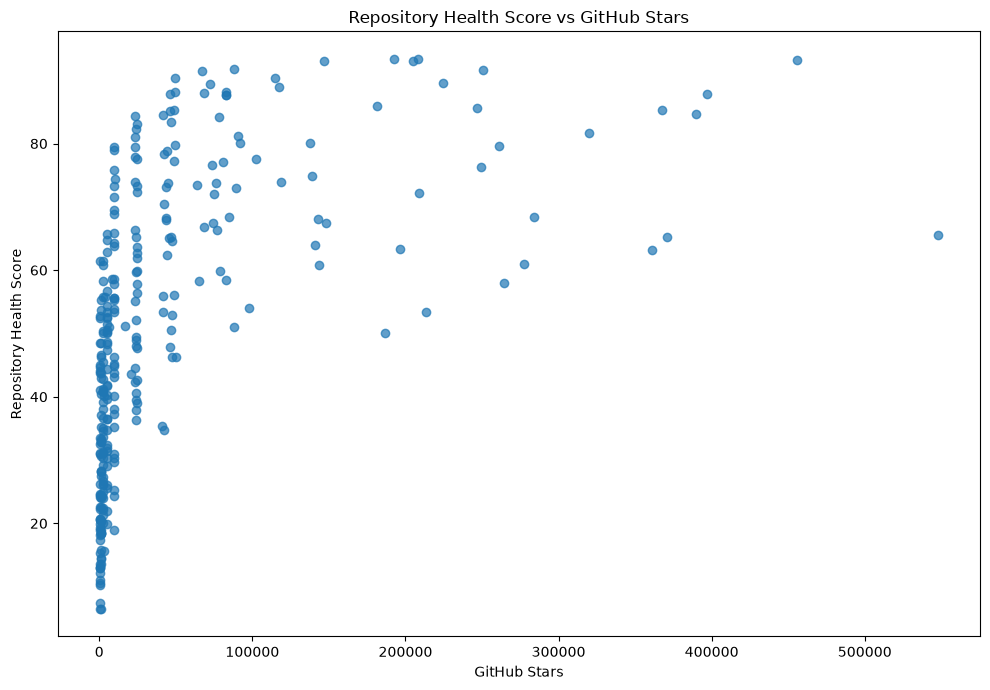

In [22]:
plt.figure(figsize=(10, 7))

plt.scatter(
    health_df["stars"],
    health_df["health_score"],
    alpha=0.7
)

plt.xlabel("GitHub Stars")
plt.ylabel("Repository Health Score")
plt.title(
    "Repository Health Score vs GitHub Stars"
)

plt.tight_layout()
plt.show()

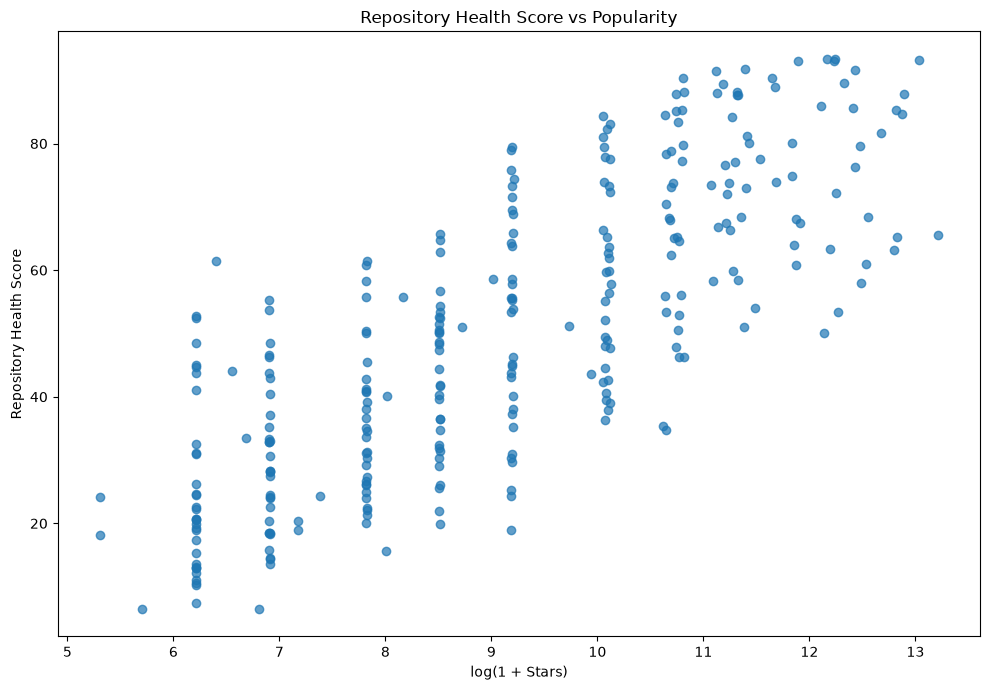

In [23]:
plt.figure(figsize=(10, 7))

plt.scatter(
    np.log1p(health_df["stars"]),
    health_df["health_score"],
    alpha=0.7
)

plt.xlabel("log(1 + Stars)")
plt.ylabel("Repository Health Score")
plt.title(
    "Repository Health Score vs Popularity"
)

plt.tight_layout()
plt.show()

In [34]:
health_star_correlation = (
    health_df[
        ["health_score", "stars"]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    f"Health Score ↔ Stars correlation: "
    f"{health_star_correlation:.4f}"
)

Health Score ↔ Stars correlation: 0.5256


In [35]:
health_df["star_rank"] = (
    health_df["stars"]
    .rank(
        ascending=False,
        method="min"
    )
)

health_df["health_rank"] = (
    health_df["health_score"]
    .rank(
        ascending=False,
        method="min"
    )
)

health_df["rank_difference"] = (
    health_df["star_rank"]
    - health_df["health_rank"]
)

In [36]:
rank_shift = (
    health_df[
        [
            "full_name",
            "stars",
            "health_score",
            "star_rank",
            "health_rank",
            "rank_difference"
        ]
    ]
    .sort_values(
        "rank_difference",
        ascending=False
    )
)

print("Repositories ranked substantially higher by Health Score:")
display(
    rank_shift.head(15)
)

print(
    "\nRepositories ranked substantially higher by stars:"
)

display(
    rank_shift.tail(15)
)

Repositories ranked substantially higher by Health Score:


,full_name,stars,health_score,star_rank,health_rank,rank_difference
133,coopcycle/coopcycle-web,601,61.389087,265.0,101.0,164.0
26,Catrobat/Paintroid,499,52.784426,266.0,136.0,130.0
239,cashubtc/nutshell,499,52.504465,266.0,138.0,128.0
220,FirefoxCSS-Store/FirefoxCSS-Store.github.io,997,55.232415,249.0,125.0,124.0
188,sampsyo/cs6120,997,53.709452,249.0,130.0,119.0
272,awslabs/mcp,9703,79.060144,158.0,42.0,116.0
235,huggingface/evaluate,2481,58.312320,224.0,111.0,113.0
115,postmanlabs/postman-collection,499,48.492058,266.0,155.0,111.0
17,symfony/security-bundle,2488,60.859440,214.0,103.0,111.0
0,pymc-devs/pymc,9754,75.795345,154.0,52.0,102.0



Repositories ranked substantially higher by stars:


,full_name,stars,health_score,star_rank,health_rank,rank_difference
208,xuebinqin/U-2-Net,9861,31.019354,135.0,228.0,-93.0
27,slab/quill,47348,46.289644,70.0,164.0,-94.0
92,purifycss/purifycss,9842,29.699789,137.0,234.0,-97.0
77,ssloy/tinyrenderer,24254,37.958695,104.0,201.0,-97.0
168,DingMouRen/LayoutManagerGroup,4972,19.852910,173.0,273.0,-100.0
290,Leonxlnx/taste-skill,87931,51.055026,41.0,143.0,-102.0
289,mattpocock/skills,264291,57.937550,11.0,113.0,-102.0
15,xdissent/ievms,9763,24.251795,152.0,254.0,-102.0
25,greenrobot/EventBus,24709,38.970915,95.0,198.0,-103.0
270,elder-plinius/CL4R1T4S,49974,46.255613,61.0,166.0,-105.0


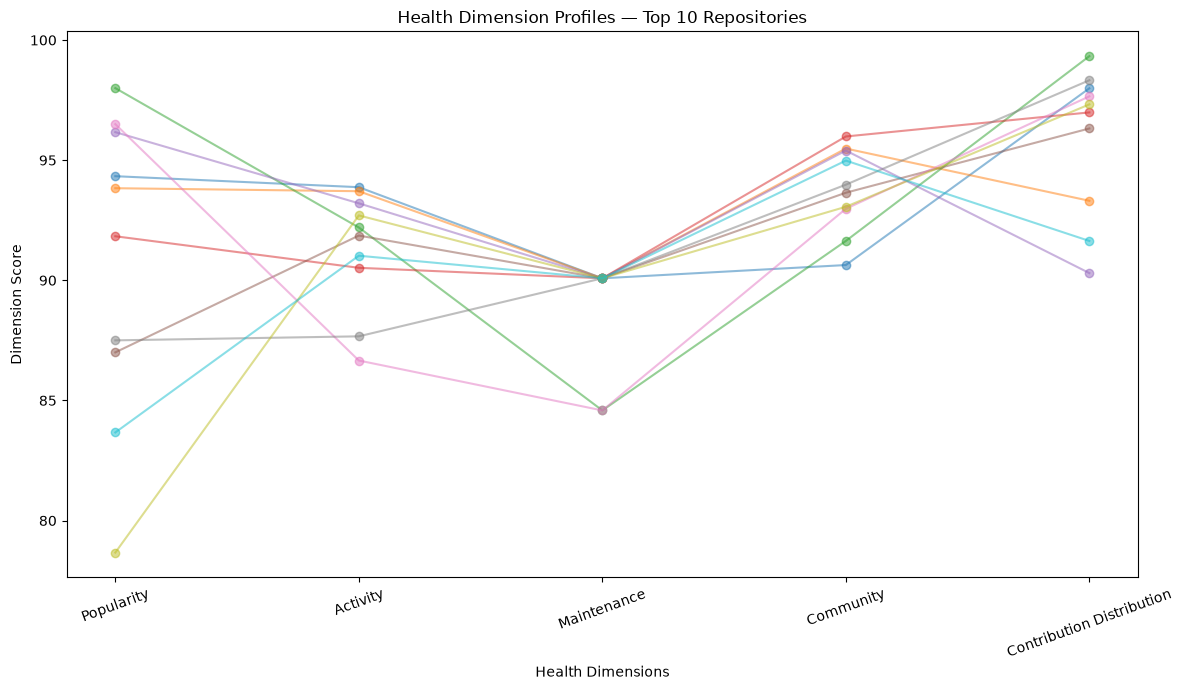

In [38]:
top10 = (
    health_df
    .nlargest(10, "health_score")
    .copy()
)

dimension_columns = [
    "popularity_score",
    "activity_score",
    "maintenance_score",
    "community_score",
    "distribution_score"
]

dimension_labels = [
    "Popularity",
    "Activity",
    "Maintenance",
    "Community",
    "Contribution Distribution"
]

plt.figure(figsize=(12, 7))

for _, row in top10.iterrows():

    plt.plot(
        dimension_labels,
        [
            row[col]
            for col in dimension_columns
        ],
        marker="o",
        alpha=0.5
    )

plt.ylabel("Dimension Score")
plt.xlabel("Health Dimensions")
plt.title(
    "Health Dimension Profiles — Top 10 Repositories"
)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [39]:
dimension_corr = health_df[
    dimension_columns
].corr()

display(dimension_corr)

,popularity_score,activity_score,maintenance_score,community_score,distribution_score
popularity_score,1.000000,0.512000,0.718308,0.605380,0.404887
activity_score,0.512000,1.000000,0.842211,0.705659,0.432603
maintenance_score,0.718308,0.842211,1.000000,0.645906,0.407535
community_score,0.605380,0.705659,0.645906,1.000000,0.606488
distribution_score,0.404887,0.432603,0.407535,0.606488,1.000000


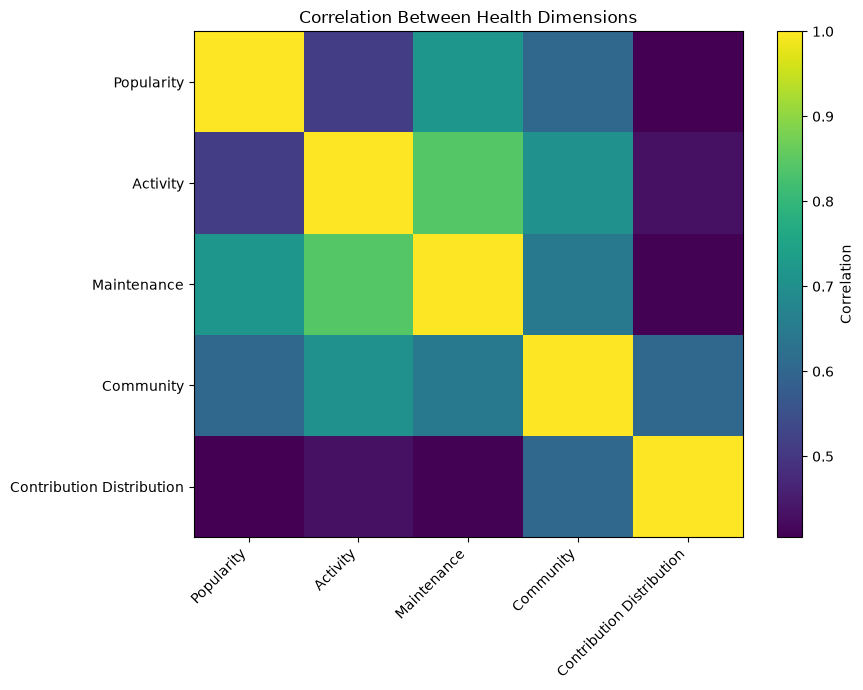

In [45]:
plt.figure(figsize=(9, 7))

plt.imshow(
    dimension_corr,
    aspect="auto"
)

plt.xticks(
    range(len(dimension_labels)),
    dimension_labels,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(dimension_labels)),
    dimension_labels
)

plt.colorbar(
    label="Correlation"
)

plt.title(
    "Correlation Between Health Dimensions"
)

plt.tight_layout()
plt.show()

In [46]:
from scipy.stats import spearmanr

# Pearson correlation with raw stars
pearson_corr = health_df[
    ["health_score", "stars"]
].corr().iloc[0, 1]

# Pearson correlation with log-transformed stars
log_star_corr = np.corrcoef(
    health_df["health_score"],
    np.log1p(health_df["stars"])
)[0, 1]

# Spearman rank correlation
spearman_corr, spearman_p = spearmanr(
    health_df["health_score"],
    health_df["stars"],
    nan_policy="omit"
)

print(f"Pearson correlation (raw stars): {pearson_corr:.4f}")
print(f"Pearson correlation (log stars): {log_star_corr:.4f}")
print(f"Spearman rank correlation: {spearman_corr:.4f}")
print(f"Spearman p-value: {spearman_p:.6e}")

Pearson correlation (raw stars): 0.5256
Pearson correlation (log stars): 0.7868
Spearman rank correlation: 0.7896
Spearman p-value: 3.560700e-65


In [47]:
validation_variables = [
    "health_score",
    "stars",
    "commits_365d",
    "contributors_count",
    "days_since_push",
    "days_since_update"
]

display(
    health_df[
        validation_variables
    ].corr()["health_score"]
    .sort_values(
        ascending=False
    )
)

health_score          1.000000
contributors_count    0.819504
stars                 0.525616
commits_365d          0.228029
days_since_update    -0.597485
days_since_push      -0.607110
Name: health_score, dtype: float64

In [48]:
display(
    health_df[
        "health_profile"
    ].value_counts()
    .sort_index()
)

health_profile
Developing    52
Moderate      97
High          99
Very High     52
Name: count, dtype: int64

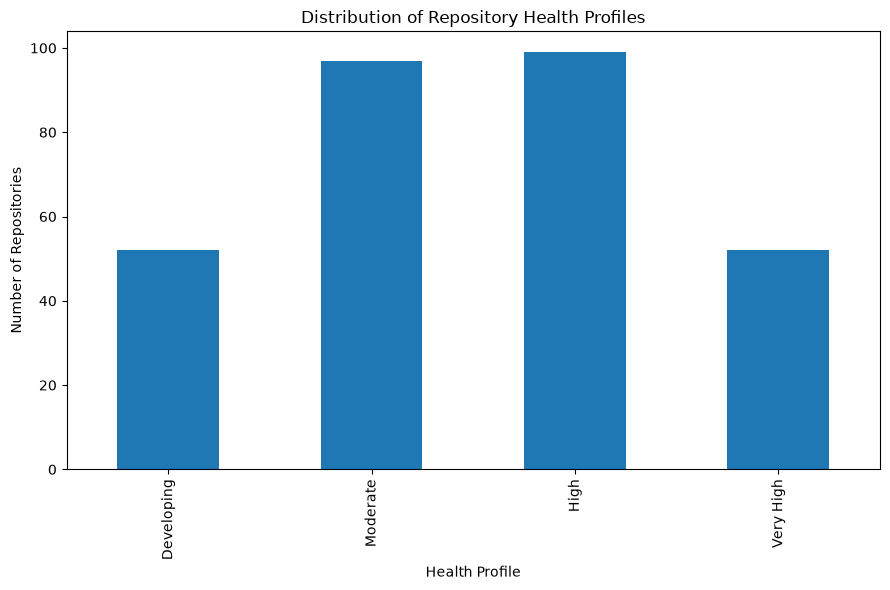

In [49]:
plt.figure(figsize=(9, 6))

health_df[
    "health_profile"
].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Health Profile")
plt.ylabel("Number of Repositories")
plt.title(
    "Distribution of Repository Health Profiles"
)

plt.tight_layout()
plt.show()

In [50]:
health_output_columns = [
    "repo_id",
    "full_name",
    "language",
    "stars",
    "forks",
    "commits_365d",
    "active_months",
    "days_since_push",
    "days_since_update",
    "contributors_count",
    "total_contributions",
    "top_contributor_share",
    "popularity_score",
    "activity_score",
    "maintenance_score",
    "community_score",
    "distribution_score",
    "health_score",
    "health_score_coverage",
    "health_profile",
    "star_rank",
    "health_rank",
    "rank_difference"
]

health_output_columns = [
    col for col in health_output_columns
    if col in health_df.columns
]

health_results = health_df[
    health_output_columns
].copy()

health_results.to_csv(
    "../reports/repository_health_scores.csv",
    index=False
)

print(
    "Repository Health Score dataset saved successfully."
)

print(
    "Shape:",
    health_results.shape
)

Repository Health Score dataset saved successfully.
Shape: (300, 23)


## Health Score Methodology Summary

The Repository Health Score is an interpretable multidimensional index rather
than a supervised prediction model.

Five dimensions are used:

| Dimension | Indicators | Direction |
|---|---|---|
| Popularity | Stars, forks | Higher is better |
| Activity | Recent commits, active months | Higher is better |
| Maintenance | Days since push, days since update | Lower is better |
| Community | Contributor count, contribution volume | Higher is better |
| Contribution Distribution | Top contributor share | Lower concentration receives higher score |

Each dimension contributes equally to the initial score.

Raw variables are converted into percentile-based scores because repository
metrics such as stars, commits and contributions are highly skewed and contain
extreme observations.

Missing measurements caused by API limitations are retained as unavailable
rather than being interpreted as zero. Health-score coverage is therefore
reported alongside the score.

The resulting score should be interpreted comparatively within the analytical
sample and not as an absolute measure of software quality.

In [51]:
# Popularity-excluded sensitivity analysis

non_popularity_dimensions = [
    "activity_score",
    "maintenance_score",
    "community_score",
    "distribution_score"
]

health_df["health_score_no_popularity"] = (
    health_df[non_popularity_dimensions]
    .mean(axis=1)
)

print("Popularity-excluded Health Index created.")

display(
    health_df[
        [
            "full_name",
            "stars",
            "health_score",
            "health_score_no_popularity"
        ]
    ]
    .sort_values(
        "health_score_no_popularity",
        ascending=False
    )
    .head(20)
)

Popularity-excluded Health Index created.


,full_name,stars,health_score,health_score_no_popularity
241,langchain-ai/langchain,146532,93.082455,93.394735
81,metabase/metabase,49310,90.366969,93.292044
101,microsoft/vscode,192634,93.384031,93.146705
274,anomalyco/opencode,208133,93.283918,93.146565
261,OpenHands/OpenHands,88307,91.782238,92.977797
5,scikit-learn/scikit-learn,67283,91.511539,92.514424
192,n8n-io/n8n,204985,93.031185,92.247314
75,freeCodeCamp/freeCodeCamp,455711,93.150021,91.937526
232,immich-app/immich,114568,90.278890,91.931946
43,react/react,250539,91.675749,90.469686


In [52]:
from scipy.stats import spearmanr

no_pop_pearson_raw = np.corrcoef(
    health_df["health_score_no_popularity"],
    health_df["stars"]
)[0, 1]

no_pop_pearson_log = np.corrcoef(
    health_df["health_score_no_popularity"],
    np.log1p(health_df["stars"])
)[0, 1]

no_pop_spearman, no_pop_p = spearmanr(
    health_df["health_score_no_popularity"],
    health_df["stars"],
    nan_policy="omit"
)

print(
    f"Popularity-excluded Pearson (raw stars): "
    f"{no_pop_pearson_raw:.4f}"
)

print(
    f"Popularity-excluded Pearson (log stars): "
    f"{no_pop_pearson_log:.4f}"
)

print(
    f"Popularity-excluded Spearman: "
    f"{no_pop_spearman:.4f}"
)

print(
    f"Spearman p-value: "
    f"{no_pop_p:.6e}"
)

Popularity-excluded Pearson (raw stars): 0.4328
Popularity-excluded Pearson (log stars): 0.6618
Popularity-excluded Spearman: 0.6629
Spearman p-value: 2.424052e-39


In [53]:
comparison = pd.DataFrame({
    "Index": [
        "Original Health Index",
        "Popularity-Excluded Index"
    ],
    "Raw_Stars_Pearson": [
        pearson_corr,
        no_pop_pearson_raw
    ],
    "Log_Stars_Pearson": [
        log_star_corr,
        no_pop_pearson_log
    ],
    "Stars_Spearman": [
        spearman_corr,
        no_pop_spearman
    ]
})

display(comparison)

,Index,Raw_Stars_Pearson,Log_Stars_Pearson,Stars_Spearman
0,Original Health Index,0.525616,0.786840,0.789633
1,Popularity-Excluded Index,0.432772,0.661847,0.662911


In [54]:
health_df["health_no_popularity_rank"] = (
    health_df["health_score_no_popularity"]
    .rank(
        ascending=False,
        method="min"
    )
)

health_df["no_popularity_rank_shift"] = (
    health_df["star_rank"]
    - health_df["health_no_popularity_rank"]
)

display(
    health_df[
        [
            "full_name",
            "stars",
            "star_rank",
            "health_score_no_popularity",
            "health_no_popularity_rank",
            "no_popularity_rank_shift"
        ]
    ]
    .sort_values(
        "no_popularity_rank_shift",
        ascending=False
    )
    .head(20)
)

,full_name,stars,star_rank,health_score_no_popularity,health_no_popularity_rank,no_popularity_rank_shift
133,coopcycle/coopcycle-web,601,265.0,73.111358,62.0,203.0
239,cashubtc/nutshell,499,266.0,62.255581,93.0,173.0
220,FirefoxCSS-Store/FirefoxCSS-Store.github.io,997,249.0,65.957186,82.0,167.0
26,Catrobat/Paintroid,499,266.0,60.938866,101.0,165.0
188,sampsyo/cs6120,997,249.0,62.178482,95.0,154.0
17,symfony/security-bundle,2488,214.0,72.136800,63.0,151.0
115,postmanlabs/postman-collection,499,266.0,56.594239,118.0,148.0
235,huggingface/evaluate,2481,224.0,65.411234,84.0,140.0
205,Neverous/efibooteditor,499,266.0,54.541614,127.0,139.0
272,awslabs/mcp,9703,158.0,85.825180,27.0,131.0


## Final Health Index Validation

The primary Repository Health Index uses five equally weighted dimensions:
Popularity, Activity, Maintenance, Community, and Contribution Distribution.

Validation against GitHub stars produced:

- Pearson correlation with raw stars: 0.5256
- Pearson correlation with log-transformed stars: 0.7868
- Spearman rank correlation: 0.7896

Because repository stars are highly skewed, rank-based and log-transformed
relationships are considered alongside the raw Pearson correlation.

A sensitivity analysis removed the explicit Popularity dimension and averaged
the remaining four dimensions:

- Pearson correlation with raw stars: 0.4328
- Pearson correlation with log-transformed stars: 0.6618
- Spearman rank correlation: 0.6629

The reduction in association demonstrates that the explicit Popularity
dimension contributes to the relationship with stars, while the remaining
Activity, Maintenance, Community and Contribution Distribution dimensions
still exhibit substantial association with repository popularity.

Therefore, OpenSourcePulse does not claim that repository health is independent
of popularity. Instead, it demonstrates that repository intelligence can be
expanded beyond star counts by incorporating multiple dimensions of activity,
maintenance and collaboration.

The popularity-excluded index is retained as a sensitivity-analysis tool and
is not used as the primary Repository Health Index.